# **Part 2: Regression Tree [20 marks]**

In this part, you will use scikit-learn's decision tree regressor and test its performance on the same dataset used in the previous part. You will be using different lookback sizes to form your data this time.

### Imports

In [1]:
# import all required libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

/var/folders/y3/k0p7pckj3096pc7w2q3_2b1h0000gn/T/ipykernel_27778/1406968305.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Regression Tree Implementation

* Write code to implement regression tree models for each lookback size ranging from 1-3. (Code modularity hint: use a blueprint for the model, and use its instances for each dataset formed from a lookback size)
* Evaluate the performance of each tree model by forming testing datasets associated with each respective lookback.

In [15]:
# code here
def process_data(file_name):
    with open(file_name, 'r') as file:
        lines = file.readlines()
    data = []
    for line in lines:          # process the lines to extract x and y coordinates
        x_str, y_str = line.strip().split(',')
        x = int(x_str)
        y = int(y_str)
        data.append([x, y])     # store x and y coordinates for each time step
    data = np.array(data)
    return data

training_data = process_data('./Dataset/Training/training_data.txt')

class RegressionTreeModel:
    def __init__(self, lookback):
        self.lookback = lookback
        self.model = DecisionTreeRegressor()

    def train(self, data):
        input_coordinates, output_coordinates = [], []
        for i in range(self.lookback, len(data)):
            sequence = data[i-self.lookback:i]  # Sequence of previous x, y values
            input_coordinates.append(sequence.flatten())  # Flatten the sequence and append it to X
            output_coordinates.append(data[i])  # Append current x, y values
        input_coordinates = np.array(input_coordinates)
        output_coordinates = np.array(output_coordinates)
        self.model.fit(input_coordinates, output_coordinates)


    def evaluate(self, data):
        input_coordinates, output_coordinates = [], []
        for i in range(self.lookback, len(data)):
            sequence = data[i-self.lookback:i]  # Sequence of previous x, y values
            input_coordinates.append(sequence.flatten())  # Flatten the sequence and append it to X
            output_coordinates.append(data[i])  # Append current x, y values
        input_coordinates = np.array(input_coordinates)
        output_coordinates = np.array(output_coordinates)
        pred_coordinates = self.model.predict(input_coordinates)
        rmse = np.sqrt(root_mean_squared_error(output_coordinates, pred_coordinates))
        return rmse
    
    def model_predict(self,data):
        input_coordinates = []
        input_coordinates.append(data.flatten())
        input_coordinates = np.array(input_coordinates)
        prediction = self.model.predict(input_coordinates)
        return prediction
    


### Evaluation and Analysis

*  Plot a line graph to evaluate your model's performance (using code for RMSE from Part 1A) across the lookback size range `i.e., 1-3`. (if any). Identify and explain any trend in how the RMSE values change with varying lookback size.

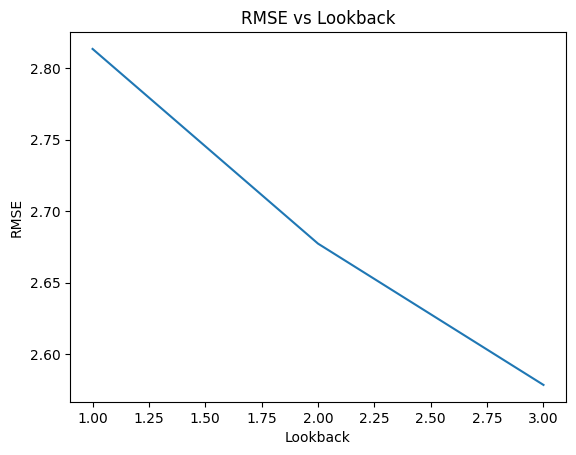

In [16]:
# code here
import matplotlib.pyplot as plt

lookbacks = range(1, 4)  # Lookback values from 1 to 20
testing_data = process_data('./Dataset/Testing/test01.txt')
rmses = []

for lookback in lookbacks:
    model = RegressionTreeModel(lookback=lookback)
    model.train(training_data)
    rmse = model.evaluate(testing_data)
    rmses.append(rmse)

plt.plot(lookbacks, rmses)
plt.xlabel('Lookback')
plt.ylabel('RMSE')
plt.title('RMSE vs Lookback')
plt.show()




    

### Double Click to $\color{green}{\text{add explanation/reasoning here}}$
The error of my model is decreasing as the lookback increases. As we are increasing the lookback we are providing the model with more information about past movements about the object. . This tends to decrease bias because the model can capture more complex relationships between the input features and the target variable. With a larger lookback, the model is less likely to underfit the data by oversimplifying the underlying patterns.

### Visualization of Actual and Predicted Path

* Modify and use same code from the previous part. The time interval should be 6 seconds (choose from wherever in the testing data).
* Generate a graph illustrating the actual and predicted paths using one of the above lookback sizes. Which one should you choose?

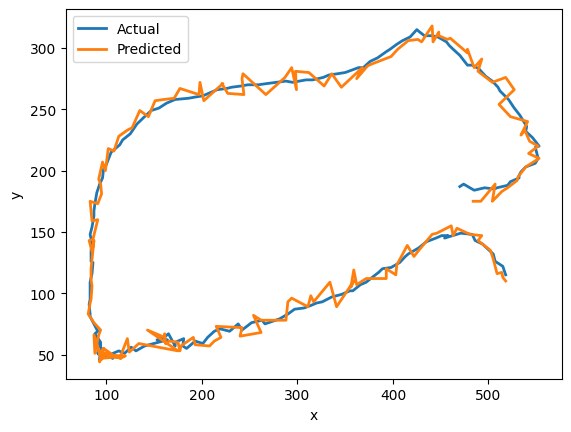

In [17]:
# code here
#using time from 3 seconds to 7 seconds
#using lookback of 3 as it has the least RMSE
model = RegressionTreeModel(lookback=3)
model.train(training_data)
testing_data = process_data('./Dataset/Testing/test01.txt')
x_actual = []
y_actual = []
x_pred = []
y_pred = []
for i in range(29,210):
    input_sequence = testing_data[i-3:i]
    prediction = model.model_predict(input_sequence)
    x_actual.append(testing_data[i+1][0])
    y_actual.append(testing_data[i+1][1])
    x_pred.append(prediction[0][0])
    y_pred.append(prediction[0][1])
plt.plot(x_actual, y_actual, label='Actual', linewidth=2)
plt.plot(x_pred, y_pred, label='Predicted', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

